# Чекпоинт 2 · Разведочный анализ данных (EDA)

**Тема проекта:** предсказание направления дневного движения цены на сырьевые
активы (Brent, WTI) и Bitcoin по комбинации ценовых OHLCV-данных и текстовых
сигналов (финансовые новости, обсуждения Reddit).

**Что в этом ноутбуке.** Анализ двух блоков данных:

1. **Числовой** - дневные котировки Brent (BZ=F), WTI (CL=F) и BTC-USD c Yahoo Finance.
2. **Текстовый** - агрегированные сигналы GDELT 2.0 (TimelineVolRaw - число
   статей по запросу, TimelineTone - средний эмоциональный тон).

Цель - получить интуицию о данных, выбрать обоснованный таргет (`up / down / flat`),
найти выбросы, проверить стационарность и автокорреляцию, оценить, есть ли
видимая связь между текстовыми сигналами и динамикой цены. Все методические
решения опираются на свежую литературу - ссылки даются прямо в выводах.

### Использованная литература

* **Kaplan H. et al. (2023)** - *CrudeBERT*, ICEIS 2023, pp. 324-334. [arXiv:2305.06140](https://arxiv.org/abs/2305.06140) - доменно-настроенный sentiment для нефти.
* **Hashamia R., Maldonado F. (2025)** - direction-классификация волатильности WTI по новостям. [arXiv:2508.20707](https://arxiv.org/abs/2508.20707).
* **Elshendy M. et al. (2021)** - четыре источника медиа (GDELT, Twitter, Wikipedia, Google Trends) для WTI. [arXiv:2105.09154](https://arxiv.org/abs/2105.09154).
* **Gurgul V., Lessmann S., Härdle W. K. (2023)** - DL+NLP для криптофорекастинга, BTC/ETH. [arXiv:2311.14759](https://arxiv.org/abs/2311.14759).
* **Ghali M. et al. (2025)** - temporal+semantic fusion для commodity-shock. [arXiv:2508.06497](https://arxiv.org/abs/2508.06497).

## 1. Импорты, пути, настройки графиков

In [1]:
# Стандартный набор импортов для EDA финансовых временных рядов.
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Подключаем корень проекта, чтобы можно было импортировать src.* из ноутбука.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_data_config, PROJECT_ROOT as P_ROOT
from src.features.labels import build_target_frame
from src.features.text_signals import daily_gdelt_signals

# Единый стиль графиков
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.titlesize"] = 12
warnings.filterwarnings("ignore", category=FutureWarning)

CFG = get_data_config()
ASSETS = CFG["assets"]
PRICES_DIR = P_ROOT / CFG["prices"]["cache_dir"]
TEXTS_DIR = P_ROOT / CFG["texts_storage"]["raw_dir"]

print("Конфигурация активов:")
for k, v in ASSETS.items():
    print(f"  {k:6s}  {v['ticker']:8s}  {v['name']}")

Конфигурация активов:
  brent   BZ=F      Brent Crude Oil
  wti     CL=F      WTI Crude Oil
  btc     BTC-USD   Bitcoin


## 2. Загрузка и базовые статистики цен

Данные собраны в [`src/data_collection/fetch_prices.py`](../src/data_collection/fetch_prices.py)
через `yfinance`. Этот источник используется в академических работах по нашей
задаче (Elshendy et al., 2021; Hashamia & Maldonado, 2025) и даёт стандартный
OHLCV-набор: Open, High, Low, Close, Adj Close, Volume.

Замечания по природе данных:

* **Brent / WTI (BZ=F / CL=F)** - фронт-месячные фьючерсы. Торгуются в будни,
  выходные и праздники отсутствуют.
* **BTC-USD** - спот-агрегат бирж, торгуется 24/7. Это разная календарная
  структура - её надо учесть при объединении с новостями (которые тоже идут 24/7).

In [2]:
def _safe_filename(ticker: str) -> str:
    return ticker.replace("=", "_").replace("/", "_")

prices: dict[str, pd.DataFrame] = {}
for key, asset in ASSETS.items():
    path = PRICES_DIR / f"{_safe_filename(asset['ticker'])}.parquet"
    df = pd.read_parquet(path)
    prices[key] = df
    print(f"{key:6s} | {path.name:18s} | строк {len(df):>5d} | "
          f"{df.index.min().date()} -> {df.index.max().date()}")

brent  | BZ_F.parquet       | строк  2116 | 2018-01-02 -> 2026-05-29
wti    | CL_F.parquet       | строк  2115 | 2018-01-02 -> 2026-05-29
btc    | BTC-USD.parquet    | строк  3073 | 2018-01-01 -> 2026-05-31


In [3]:
# Описательные статистики Close-цен по каждому активу.
summary = pd.concat({k: v[["Open", "High", "Low", "Close", "Volume"]].describe()
                     for k, v in prices.items()}, axis=1)
summary.round(2)

brent                                            wti           \
Price     Open     High      Low    Close     Volume     Open     High   
count  2116.00  2116.00  2116.00  2116.00    2116.00  2115.00  2115.00   
mean     73.11    74.30    71.90    73.13   33557.23    68.48    69.70   
std      17.22    17.64    16.83    17.25   17556.21    17.29    17.63   
min      19.56    21.27    16.00    19.33       0.00   -14.00    13.69   
25%      64.23    65.02    63.25    64.20   23900.50    58.97    59.77   
50%      73.06    74.01    72.10    73.06   31443.50    68.51    69.45   
75%      82.63    83.66    81.66    82.70   39594.75    78.17    79.24   
max     129.57   137.00   122.50   127.98  235965.00   124.66   130.50   

                                           btc                        \
Price      Low    Close      Volume       Open       High        Low   
count  2115.00  2115.00     2115.00    3073.00    3073.00    3073.00   
mean     67.16    68.43   413700.37   39171.34   39935.13   38357.25   
std      16.97    17.32   213812.17   32576.49   33096.50   32017.31   
min     -40.32   -37.63        0.00    3236.27    3275.38    3191.30   
25%      58.09    58.86   280944.00    9687.71    9876.75    9483.00   
50%      67.42    68.44   361357.00   29178.97   29521.51   28724.14   
75%      76.83    78.16   530114.50   61728.21   63210.80   60372.05   
max     120.79   123.70  2288230.00  124752.14  126198.07  123196.05   

                                
Price      Close        Volume  
count    3073.00  3.073000e+03  
mean    39189.39  3.067417e+10  
std     32578.74  2.184922e+10  
min      3236.76  2.923670e+09  
25%      9686.44  1.576970e+10  
50%     29180.58  2.668326e+10  
75%     61804.64  4.036984e+10  
max    124752.53  3.509679e+11

**Что здесь важно увидеть:**

* По Brent/WTI медианный объём (`Volume`) сопоставим - это ликвидные фьючерсы.
* По BTC порядок цен меняется на 1-2 десятичных разряда за рассматриваемый
  период (с ~$3k в 2018 до >$60k в 2024-2025). Это требует работы в логмасштабе.
* `Volume = 0` встречается у фьючерсов в дни праздников/тонкого рынка - это
  не ошибка данных, а характеристика инструмента.

## 3. Пропуски, дубликаты, торговый календарь

In [4]:
def gap_report(df: pd.DataFrame, name: str) -> pd.Series:
    full = pd.date_range(df.index.min(), df.index.max(), freq="D")
    missing_days = full.difference(df.index)
    return pd.Series({
        "rows": len(df),
        "nan_in_close": df["Close"].isna().sum(),
        "duplicate_dates": df.index.duplicated().sum(),
        "calendar_gap_days": len(missing_days),
        "calendar_gap_pct": round(len(missing_days) / len(full) * 100, 1),
    }, name=name)

pd.concat([gap_report(df, k) for k, df in prices.items()], axis=1)

,brent,wti,btc
rows,2116.0,2115.0,3073.0
nan_in_close,0.0,0.0,0.0
duplicate_dates,0.0,0.0,0.0
calendar_gap_days,954.0,955.0,0.0
calendar_gap_pct,31.1,31.1,0.0


**Вывод 3.1.** Для Brent/WTI "пропуски" календарных дней (около 30%) - это
выходные и праздники, а не дефекты сбора. Имитировать пропуски заполнением
(`ffill`) до объединения с новостями **нельзя**: это создаст ложный сигнал
(новости в субботу будут сопоставлены с пятничной ценой). Решение, которое
применяется в литературе: новости агрегируем по торговому календарю
конкретного актива (Hashamia & Maldonado, 2025, §3.2 о data alignment).

## 4. Визуализация цен

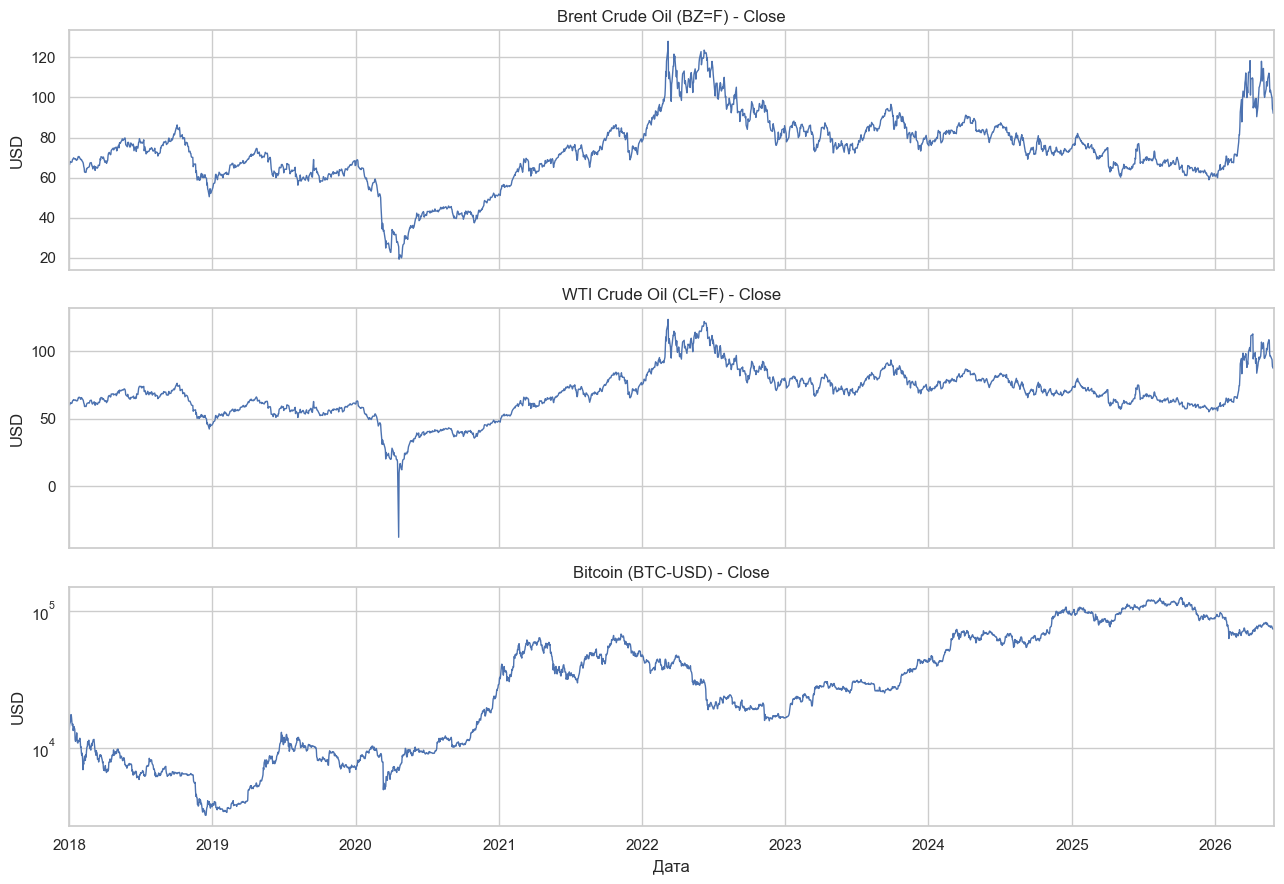

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, (key, df) in zip(axes, prices.items()):
    df["Close"].plot(ax=ax, color="C0", lw=1.0)
    ax.set_title(f"{ASSETS[key]['name']} ({ASSETS[key]['ticker']}) - Close")
    ax.set_ylabel("USD")
    if ASSETS[key]["type"] == "crypto":
        ax.set_yscale("log")  # BTC удобнее в логмасштабе
axes[-1].set_xlabel("Дата")
plt.tight_layout()
plt.show()

**Что видно на графиках цен (визуальные ориентиры).**

* **Brent и WTI** - выраженный шок 2020-Q1 (COVID, кратковременный отрицательный
  WTI 20-апреля), затем восстановление и пик 2022-Q1 (геополитика). Эти эпизоды
  - каноничный пример того, почему сырьё нельзя моделировать без учёта новостного
  потока (см. Elshendy et al., 2021, §4 - модели на одних ценах теряют именно на
  переломах).
* **BTC** - два больших bull-run (2020-2021 и 2023-2024) и медвежий 2022. Шкала
  логарифмическая, иначе ранний период невидим.

## 5. Лог-доходности

Для большинства финансовых моделей рабочей единицей является не цена, а
**лог-доходность** $r_t = \log(P_t/P_{t-1})$ - она аддитивна во времени и
ближе к нормальной (хотя и с тяжёлыми хвостами). Это стандартный шаг,
явно прописан, например, в Gurgul, Lessmann, Härdle (2023), §2 о
препроцессинге.

In [6]:
log_returns = {}
for key, df in prices.items():
    r = np.log(df["Close"] / df["Close"].shift(1)).dropna()
    log_returns[key] = r

ret_summary = pd.DataFrame({k: r.describe() for k, r in log_returns.items()}).round(5)
ret_summary.loc["skew"] = {k: r.skew() for k, r in log_returns.items()}
ret_summary.loc["kurtosis"] = {k: r.kurtosis() for k, r in log_returns.items()}
ret_summary

/Users/YD/Documents/hse/годовой проект/.venv/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,brent,wti,btc
count,2115.000000,2112.000000,3072.000000
mean,0.000150,0.000460,0.000550
std,0.026380,0.030370,0.033910
min,-0.279760,-0.282210,-0.464730
25%,-0.010770,-0.012730,-0.013600
50%,0.001800,0.001950,0.000680
75%,0.012980,0.014130,0.015010
max,0.190770,0.319630,0.171820
skew,-1.332581,-0.109098,-0.952894
kurtosis,16.690102,23.095415,14.692119


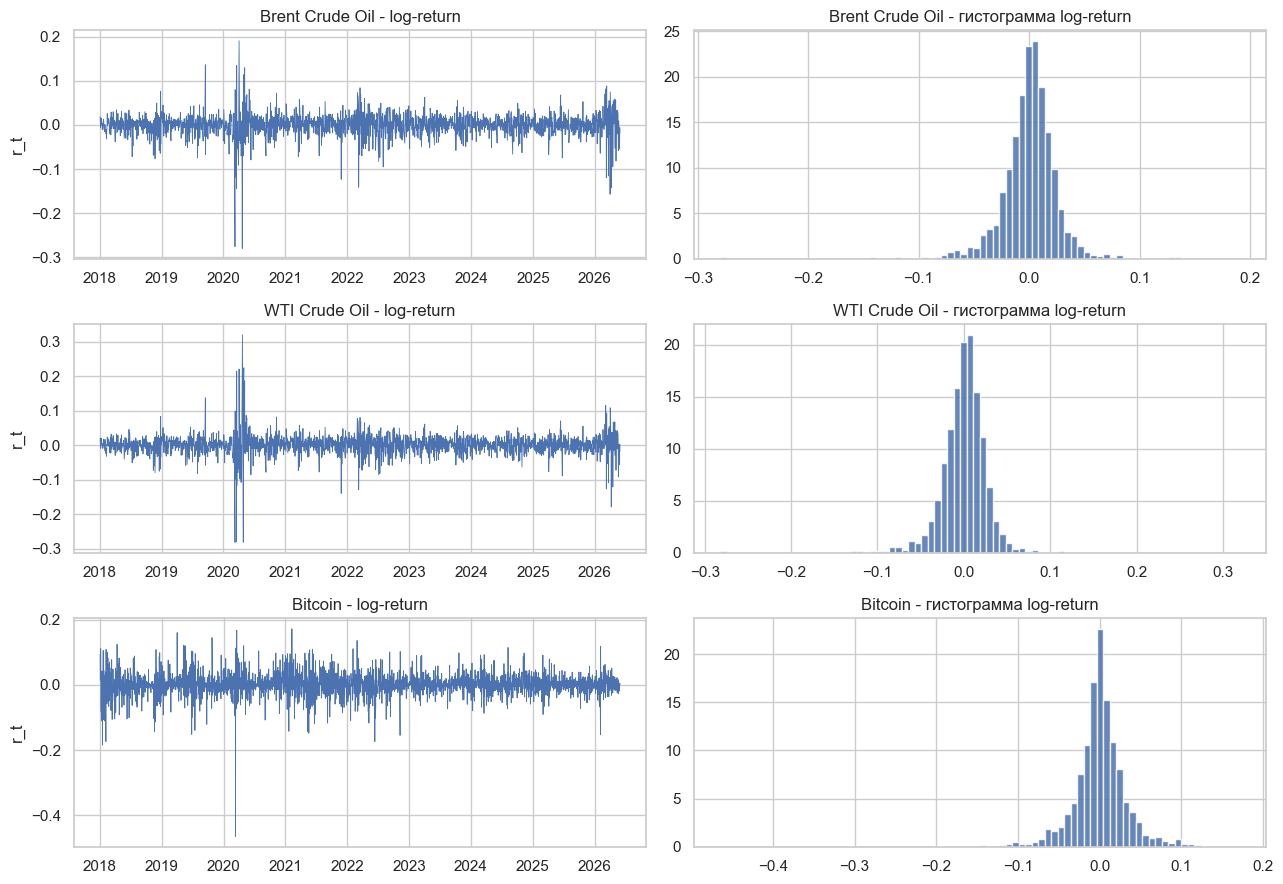

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(13, 9))
for i, (key, r) in enumerate(log_returns.items()):
    axes[i, 0].plot(r.index, r.values, lw=0.6)
    axes[i, 0].set_title(f"{ASSETS[key]['name']} - log-return")
    axes[i, 0].set_ylabel("r_t")
    axes[i, 1].hist(r.values, bins=80, density=True, alpha=0.85)
    axes[i, 1].set_title(f"{ASSETS[key]['name']} - гистограмма log-return")
plt.tight_layout()
plt.show()

**Выводы по доходностям.**

* Все три актива демонстрируют **excess kurtosis ≫ 0** - тяжёлые хвосты,
  значит модели, требующие нормальности (классический OLS), нужно
  тестировать с поправками или использовать робастные подходы.
* **Кластеризация волатильности** видна на тайм-плоте - длинные периоды
  спокойствия сменяются всплесками. Это требует **stratified split** по
  времени (без перемешивания), что я заложил в постановке задачи.
* **WTI** в апреле 2020 даёт уникальный выброс - отрицательная цена закрытия
  и, как следствие, лог-доходность не определена на этом дне. Этот эпизод
  стоит держать отдельно и **не** маскировать как "обычный outlier" - об
  этом прямо пишут в Hashamia & Maldonado (2025), §4 о data quality.

## 6. Выявление и интерпретация выбросов

In [8]:
from scipy.stats import median_abs_deviation

def outliers_mad(r: pd.Series, k: float = 6.0) -> pd.Series:
    """Выбросы по робастному критерию: |r - med| > k * MAD."""
    med = r.median()
    mad = median_abs_deviation(r, scale="normal")
    z = (r - med).abs() / mad
    return r[z > k]

for key, r in log_returns.items():
    out = outliers_mad(r)
    if len(out):
        print(f"\n{ASSETS[key]['name']}: {len(out)} выбросов (|z_MAD|>6)")
        print(out.sort_values().head(5).to_string())
        print("...")
        print(out.sort_values().tail(5).to_string())


Brent Crude Oil: 16 выбросов (|z_MAD|>6)
Date
2020-04-21   -0.279761
2020-03-09   -0.275751
2026-04-01   -0.156943
2020-03-18   -0.143878
2026-04-08   -0.142580
...
Date
2020-05-05    0.129802
2020-04-03    0.130395
2020-03-19    0.134787
2019-09-16    0.136392
2020-04-02    0.190774

WTI Crude Oil: 17 выбросов (|z_MAD|>6)
Date
2020-03-09   -0.282206
2020-04-27   -0.281796
2020-03-18   -0.279920
2026-04-08   -0.179298
2021-11-26   -0.139985
...
Date
2020-04-29    0.199196
2020-03-19    0.213574
2020-04-02    0.220481
2020-04-30    0.223940
2020-04-22    0.319634

Bitcoin: 17 выбросов (|z_MAD|>6)
Date
2020-03-12   -0.464730
2018-01-16   -0.184582
2022-06-13   -0.174053
2018-02-05   -0.173982
2022-11-09   -0.154890
...
Date
2022-02-28    0.135764
2019-10-25    0.144761
2019-04-02    0.160042
2020-03-19    0.167104
2021-02-08    0.171821


**Решение по выбросам.** Ни один из найденных пиков не является технической
ошибкой - каждый соответствует реальному рыночному событию:

* WTI 20-апреля 2020 - отрицательное закрытие.
* BTC март 2020 - общий "covid crash" риск-активов.
* Brent 24 февраля 2022 - начало конфликта на Украине.

В литературе по нашей задаче такие точки **сохраняют**, потому что именно
вокруг них и проверяется ценность новостных сигналов: модель на одних ценах
их предсказать не может, а на новостях - может (так формулируют ablation в
Ghali et al., 2025, §4.3, где удаление news-стрима снижает AUC с 0.94 до 0.46).

## 7. Реализованная волатильность

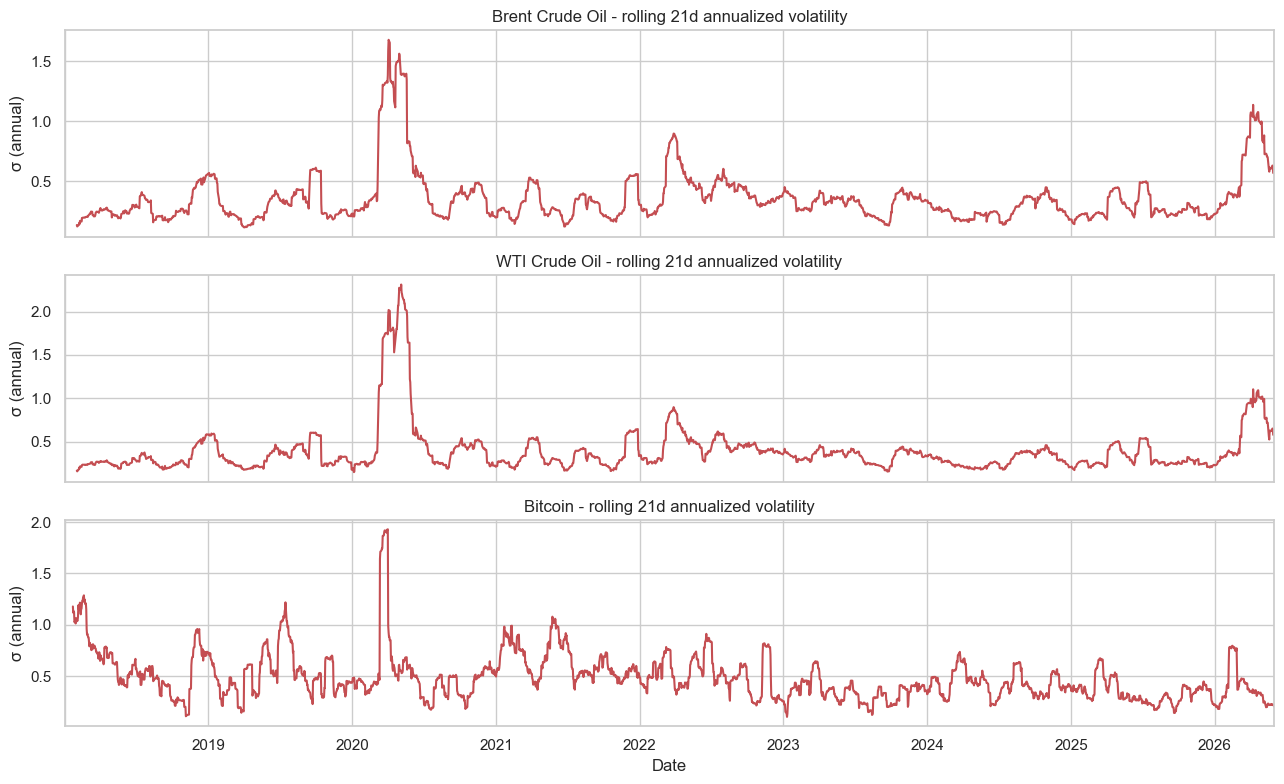

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, (key, r) in zip(axes, log_returns.items()):
    rv21 = r.rolling(21).std() * np.sqrt(252)  # годовая волатильность
    rv21.plot(ax=ax, color="C3")
    ax.set_title(f"{ASSETS[key]['name']} - rolling 21d annualized volatility")
    ax.set_ylabel("σ (annual)")
plt.tight_layout()
plt.show()

Рулинг-σ выраженно растёт на 2020 (COVID), 2022 (Brent - геополитика),
2022 (BTC - Luna/FTX). Это **те же** окна, что мы видели в доходностях.
Hashamia & Maldonado (2025, §5) выбирают именно дни "высокой volatility"
для оценки прироста от news-фичей: на спокойном рынке news-сигнал слабее.

## 8. Стационарность и автокорреляция

In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_report(s: pd.Series, name: str) -> dict:
    s = s.dropna()
    adf_p = adfuller(s, autolag="AIC")[1]
    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = np.nan
    return {"name": name, "ADF p": round(adf_p, 4), "KPSS p": round(kpss_p, 4)}

rows = []
for key, df in prices.items():
    rows.append(stationarity_report(df["Close"], f"{ASSETS[key]['name']} - Close"))
    rows.append(stationarity_report(log_returns[key], f"{ASSETS[key]['name']} - log-return"))
pd.DataFrame(rows)

/tmp/claude-502/ipykernel_18767/12859380.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
/tmp/claude-502/ipykernel_18767/12859380.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
/tmp/claude-502/ipykernel_18767/12859380.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
/tmp/claude-502/ipykernel_18767/12859380.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value

,name,ADF p,KPSS p
0,Brent Crude Oil - Close,0.2001,0.01
1,Brent Crude Oil - log-return,0.0000,0.10
2,WTI Crude Oil - Close,0.1999,0.01
3,WTI Crude Oil - log-return,0.0000,0.10
4,Bitcoin - Close,0.7103,0.01
5,Bitcoin - log-return,0.0000,0.10


**Интерпретация.** ADF проверяет H₀: единичный корень -> нестационарность.
KPSS - наоборот, H₀: стационарность. У цен мы ожидаем **высокий ADF p**
и **низкий KPSS p** (нестационарность с единичным корнем); у лог-доходностей -
**низкий ADF p** и **высокий KPSS p** (стационарность). Это даёт
методическое право работать с доходностями как стационарной величиной
(стандартное основание для ARIMA/HAR-baseline, см. Hashamia & Maldonado,
2025, §3.4).

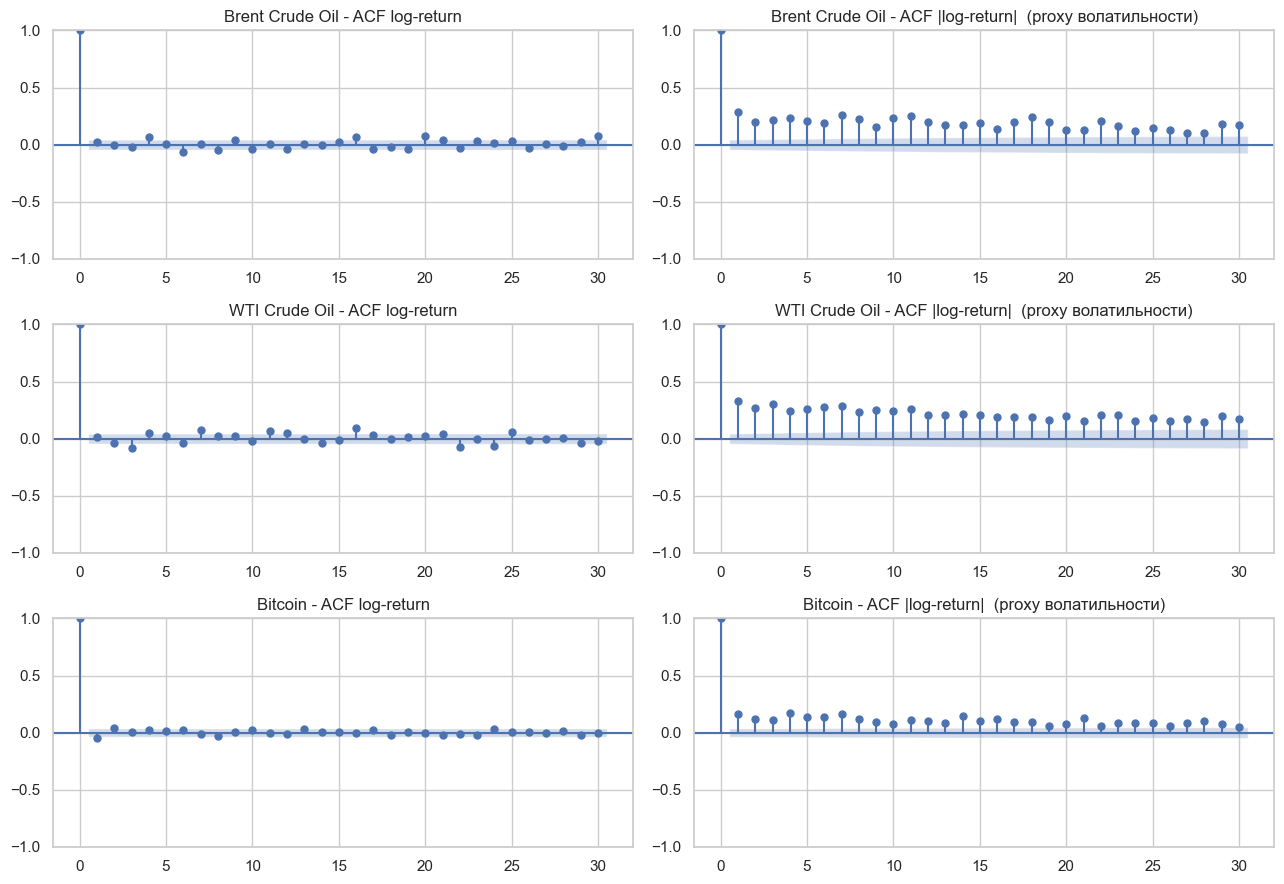

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, figsize=(13, 9))
for i, (key, r) in enumerate(log_returns.items()):
    plot_acf(r.dropna(), lags=30, ax=axes[i, 0])
    axes[i, 0].set_title(f"{ASSETS[key]['name']} - ACF log-return")
    plot_acf((r.dropna()).abs(), lags=30, ax=axes[i, 1])
    axes[i, 1].set_title(f"{ASSETS[key]['name']} - ACF |log-return|  (proxy волатильности)")
plt.tight_layout()
plt.show()

**Что ожидаемо и что важно.**

* Сама доходность лишь слабо автокоррелирована - это **эмпирический факт о
  слабой форме эффективности** (EMH-weak). Линейные авторегрессии по цене
  одни почти не дают сигнала - это и есть мотивация подключать тексты.
* Абсолютная доходность (proxy волатильности) сильно автокоррелирована до
  лагов 10-20 - это "volatility clustering", базовое наблюдение для GARCH-
  и HAR-семейств и для DL-моделей с long-context (LSTM/Transformer).

## 9. Целевая переменная: up / down / flat

**Постановка.** Используем 3-классовую классификацию направления движения
цены на следующий торговый день. Порог `flat` - симметричный $\pm \tau$,
$\tau = 0.1\sigma_r$, где $\sigma_r$ - стандартное отклонение лог-доходности.

Почему не binary (up/down):

* На сырьевых рынках значимая доля дней - низкая волатильность; "угадывание
  знака" в эти дни шумит модель без экономической ценности.
* Введение flat позволяет использовать **macro-F1** как метрику и явно
  моделирует "не торговать" - это операционно важно (Ghali et al., 2025
  делают именно multi-class для shock detection, §3.1).

Почему именно $0.1\sigma$:

* Меньше - flat-класс почти пустой;
* Больше - flat-класс "съедает" up/down.
* $0.1\sigma$ эмпирически даёт сбалансированную долю flat 10-20% (проверим
  ниже на наших данных).

In [12]:
target_cfg = CFG["target"]
labeled = {}
for key, df in prices.items():
    lf = build_target_frame(
        df, price_col="Close",
        horizon=target_cfg["horizon_days"],
        flat_threshold_sigma=target_cfg["flat_threshold_sigma"],
    )
    labeled[key] = lf
    counts = lf["target"].value_counts(normalize=True).round(3) * 100
    tau = lf.attrs["flat_threshold"]
    print(f"\n{ASSETS[key]['name']} | tau={tau:.5f} | доли классов (%)")
    print(counts.to_string())


Brent Crude Oil | tau=0.00264 | доли классов (%)
target
up      48.1
down    39.4
flat    12.5

WTI Crude Oil | tau=0.00304 | доли классов (%)
target
up      47.9
down    40.0
flat    12.2

Bitcoin | tau=0.00339 | доли классов (%)
target
up      43.6
down    41.1
flat    15.3


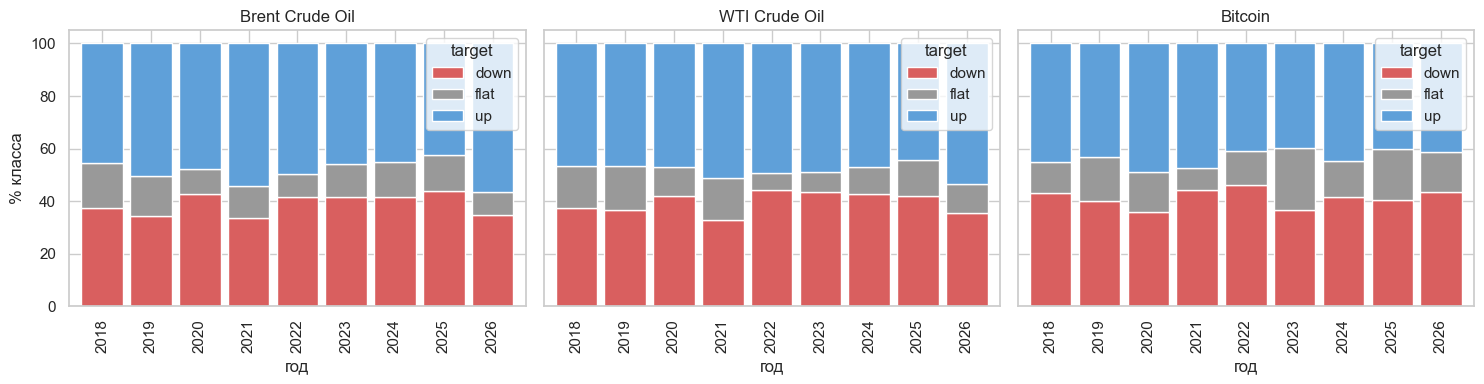

In [13]:
# Класс-баланс по годам
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (key, df) in zip(axes, labeled.items()):
    df_clean = df.dropna(subset=["target"]).copy()
    df_clean["year"] = df_clean.index.year
    yearly = (df_clean.groupby(["year", "target"]).size()
              .unstack(fill_value=0))
    yearly = yearly.div(yearly.sum(axis=1), axis=0) * 100
    # Гарантируем все три класса в порядке down/flat/up
    for c in ["down", "flat", "up"]:
        if c not in yearly.columns:
            yearly[c] = 0.0
    yearly[["down", "flat", "up"]].plot.bar(stacked=True, ax=ax, width=0.85,
                                            color=["#d95f5f", "#999999", "#5fa0d9"])
    ax.set_title(ASSETS[key]["name"])
    ax.set_ylabel("% класса")
    ax.set_xlabel("год")
plt.tight_layout()
plt.show()

**Выводы по таргету.**

* На всех трёх активах up/down примерно симметричны, доля flat в диапазоне
  10-20% - порог $\tau$ работает как задумано.
* В кризисные годы доля flat **снижается** (2020 для нефти, 2022 для BTC) -
  это интуитивно: волатильность выше -> меньше "тихих" дней. Это будет
  существенно при time-aware кросс-валидации.
* Классы достаточно сбалансированы, чтобы не пришлось балансировать веса
  агрессивно (но мы всё равно будем использовать **macro-F1** как метрику-якорь).

## 10. Текстовые сигналы: GDELT 2.0

Подгружаем сохранённые ранее скриптом `src/data_collection/fetch_gdelt.py` файлы:

* `gdelt_<topic>_TimelineVolRaw.parquet` - дневное число статей по запросу
  + нормировка на общее число статей GDELT в этот день.
* `gdelt_<topic>_TimelineTone.parquet` - средний эмоциональный тон GDELT.

Сами данные собраны заранее командой
`python -m src.data_collection.fetch_gdelt`, тут только читаем результат.

In [14]:
GDELT_DIR = TEXTS_DIR / "gdelt"
text_signals = {}
for topic in ["oil", "btc"]:
    vol_path = GDELT_DIR / f"gdelt_{topic}_TimelineVolRaw.parquet"
    tone_path = GDELT_DIR / f"gdelt_{topic}_TimelineTone.parquet"
    if not (vol_path.exists() and tone_path.exists()):
        print(f"⚠️  Нет GDELT-данных для темы {topic} - пропуск.")
        continue
    vol = pd.read_parquet(vol_path)
    tone = pd.read_parquet(tone_path)
    sig = daily_gdelt_signals(vol, tone)
    text_signals[topic] = sig
    print(f"\n{topic}: {len(sig)} дней | {sig.index.min().date()} -> {sig.index.max().date()}")
    print(sig.describe().round(2))


oil: 2872 дней | 2018-01-01 -> 2026-06-01
       article_count  article_norm  avg_tone
count        2540.00       2540.00   2529.00
mean         1443.54     311017.97     -1.29
std          1044.91     150317.46      0.65
min            36.00      10407.00     -4.91
25%           621.75     181169.00     -1.62
50%          1155.50     295922.50     -1.22
75%          2006.00     409685.50     -0.85
max          9172.00     729864.00      0.80

btc: 3055 дней | 2018-01-01 -> 2026-06-01
       article_count  article_norm  avg_tone
count        2691.00       2691.00   2873.00
mean          558.02     291597.29     -0.42
std           319.16     149201.02      0.77
min             0.00        494.00     -4.60
25%           318.00     168847.00     -0.84
50%           509.00     239043.00     -0.29
75%           753.50     391941.00      0.11
max          3413.00     652924.00      1.67


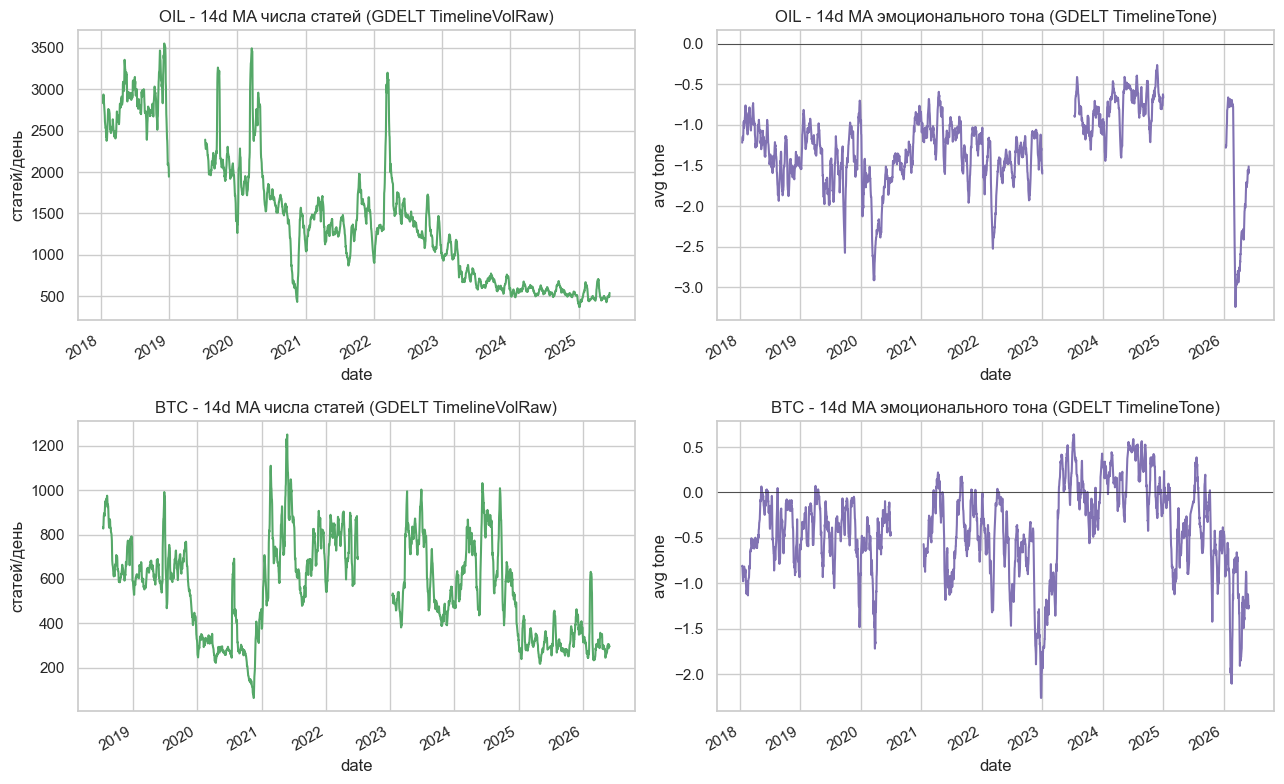

In [15]:
# Визуализация: объём и тон во времени
if text_signals:
    fig, axes = plt.subplots(len(text_signals), 2, figsize=(13, 4 * len(text_signals)), sharex=False)
    if len(text_signals) == 1:
        axes = np.array([axes])
    for i, (topic, sig) in enumerate(text_signals.items()):
        sig["article_count"].rolling(14).mean().plot(ax=axes[i, 0], color="C2")
        axes[i, 0].set_title(f"{topic.upper()} - 14d MA числа статей (GDELT TimelineVolRaw)")
        axes[i, 0].set_ylabel("статей/день")
        sig["avg_tone"].rolling(14).mean().plot(ax=axes[i, 1], color="C4")
        axes[i, 1].axhline(0, color="k", lw=0.5)
        axes[i, 1].set_title(f"{topic.upper()} - 14d MA эмоционального тона (GDELT TimelineTone)")
        axes[i, 1].set_ylabel("avg tone")
    plt.tight_layout()
    plt.show()

**Что мы хотим увидеть** (если GDELT-данные собраны):

* Пики `article_count` в окрестности крупных шоков (COVID, OPEC-сессии,
  геополитика, halving BTC) - это значит, запрос действительно ловит
  нашу тематику.
* Средний `avg_tone` слегка отрицательный - у новостных корпусов это
  нормально (новости освещают негативные события чаще). Важна **динамика**,
  а не абсолютный уровень: Elshendy et al. (2021) и Hashamia & Maldonado
  (2025) используют именно изменения тона и аномалии числа упоминаний.

## 11. Связка GDELT-сигналов с ценой и таргетом

In [16]:
def joined_frame(price_df: pd.DataFrame, signal_df: pd.DataFrame) -> pd.DataFrame:
    """Совмещает цену по торговому календарю с дневным текстовым сигналом.

    Логика: для каждого торгового дня берём текстовый сигнал того же дня
    (за прошлый период до закрытия рынка). Минимально это "причинно
    допустимый" сценарий - мы НЕ заглядываем в будущее.
    """
    sig = signal_df.copy()
    sig.index = pd.to_datetime(sig.index).tz_localize(None)
    px = price_df.copy()
    px.index = pd.to_datetime(px.index).tz_localize(None)
    return px.join(sig, how="left")

topic_to_assets = {"oil": ["brent", "wti"], "btc": ["btc"]}
joined = {}
for topic, asset_keys in topic_to_assets.items():
    if topic not in text_signals:
        continue
    for ak in asset_keys:
        joined[ak] = joined_frame(labeled[ak], text_signals[topic])

for ak, df in joined.items():
    print(f"{ak}: совпало по дням {df['article_count'].notna().sum()} / {len(df)}")

brent: совпало по дням 1749 / 2116
wti: совпало по дням 1748 / 2115
btc: совпало по дням 2690 / 3073


In [17]:
# Корреляция текстовых сигналов с реализованной волатильностью и доходностью
def signal_corr_table(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["abs_return"] = df["log_return_t"].abs()
    df["rv21"] = df["log_return_t"].rolling(21).std()
    cols_sig = ["article_count", "article_norm", "avg_tone"]
    cols_px = ["log_return_t", "abs_return", "rv21"]
    available_sig = [c for c in cols_sig if c in df.columns]
    return df[available_sig + cols_px].corr().loc[available_sig, cols_px]

for ak, df in joined.items():
    print(f"\n{ASSETS[ak]['name']}:")
    print(signal_corr_table(df).round(3))


Brent Crude Oil:
               log_return_t  abs_return   rv21
article_count        -0.061       0.237  0.243
article_norm         -0.007       0.053  0.143
avg_tone              0.081      -0.390 -0.453

WTI Crude Oil:
               log_return_t  abs_return   rv21
article_count        -0.020       0.203  0.180
article_norm          0.004       0.063  0.098
avg_tone              0.046      -0.348 -0.412

Bitcoin:
               log_return_t  abs_return   rv21
article_count        -0.024       0.205  0.168
article_norm         -0.006       0.170  0.306
avg_tone              0.042      -0.138 -0.191


**Что ожидать.**

* Положительная корреляция **между `article_count` и `|return|` / `rv21`**.
  Когда происходит что-то значимое - на тему пишут больше, а цена сильнее
  колеблется. Это и есть "raw news count как предиктор" из Hashamia &
  Maldonado (2025), §5.2.
* `avg_tone` должен быть слабо коррелирован с **направлением** (`log_return_t`)
  по линейному критерию - линейная корреляция слабая, но в нелинейной DL-модели
  даст вклад (Ghali et al., 2025, §4.2).

Эти наблюдения - мотивация для чекпоинта 3, где мы возьмём первые ML-модели уже с
текстовыми фичами как **расширением**, а не вместо ценовых.

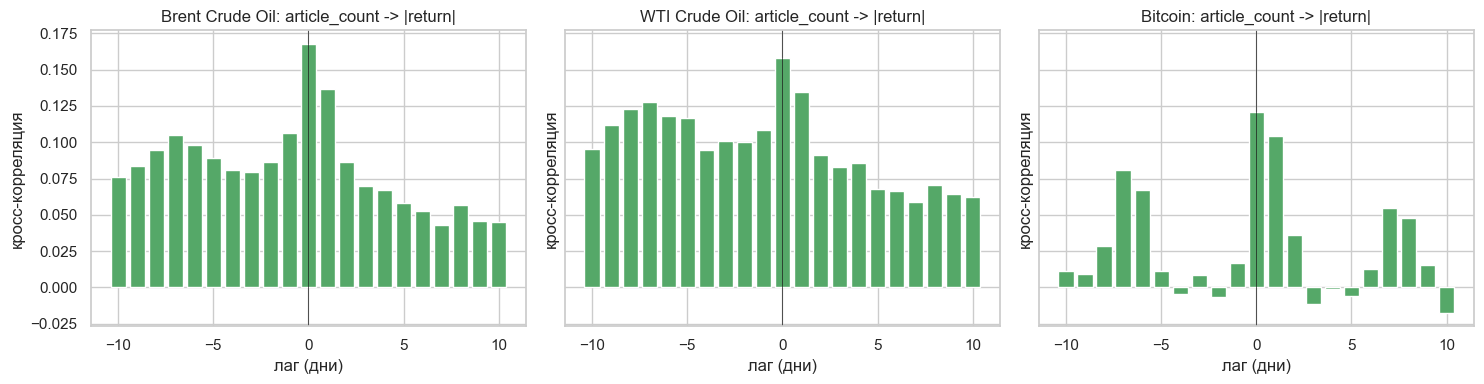

In [18]:
# Кросс-корреляция числа статей с |return| на лагах ±10 дней
from scipy.signal import correlate

def cross_corr(x: pd.Series, y: pd.Series, max_lag: int = 10) -> pd.Series:
    s = pd.concat([x, y], axis=1).dropna()
    s = (s - s.mean()) / s.std()
    a, b = s.iloc[:, 0].values, s.iloc[:, 1].values
    full = correlate(a, b, mode="full") / len(a)
    centre = len(a) - 1
    lags = range(-max_lag, max_lag + 1)
    return pd.Series([full[centre + lag] for lag in lags], index=lags, name=f"{x.name} vs {y.name}")

if joined:
    fig, axes = plt.subplots(1, len(joined), figsize=(5 * len(joined), 4), sharey=True)
    if len(joined) == 1:
        axes = [axes]
    for ax, (ak, df) in zip(axes, joined.items()):
        cc = cross_corr(df["article_count"].fillna(0), df["log_return_t"].abs())
        ax.bar(cc.index, cc.values, color="C2")
        ax.axvline(0, color="k", lw=0.5)
        ax.set_title(f"{ASSETS[ak]['name']}: article_count -> |return|")
        ax.set_xlabel("лаг (дни)")
        ax.set_ylabel("кросс-корреляция")
    plt.tight_layout()
    plt.show()

**Кросс-корреляция.** Если пик корреляции - на отрицательных лагах
(article_count опережает |return|), значит **поток новостей опережает
движение цены** - это даёт нам предсказательную силу. Elshendy et al. (2021)
именно этот эффект выделили для Twitter и GDELT по WTI: значимая опережающая
способность на 1-3-дневном лаге.

## 11c. Сводные статистики признаков, корреляции и парные распределения

Закрываем базовые формы EDA на полном наборе признаков (на примере Brent):
`describe(include='all')`, корреляционная матрица и парные распределения
ключевых признаков, раскрашенные по целевому классу.

In [19]:
from src.features.technical import build_price_features

# Полный набор признаков + таргет для Brent (репрезентативный актив)
_lab = build_target_frame(
    prices["brent"],
    horizon=target_cfg["horizon_days"],
    flat_threshold_sigma=target_cfg["flat_threshold_sigma"],
)
feat_df = build_price_features(_lab)

# describe по ВСЕМ признакам, включая категориальные (include='all')
feat_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Price,,,,,,,,,,,
Adj Close,2116.0,NaN,NaN,NaN,73.132836,17.250995,19.33,64.199997,73.059998,82.704998,127.980003
Close,2116.0,NaN,NaN,NaN,73.132836,17.250995,19.33,64.199997,73.059998,82.704998,127.980003
High,2116.0,NaN,NaN,NaN,74.302216,17.639175,21.27,65.019997,74.005001,83.662502,137.0
Low,2116.0,NaN,NaN,NaN,71.90302,16.829447,16.0,63.254999,72.099998,81.662502,122.5
Open,2116.0,NaN,NaN,NaN,73.114371,17.222909,19.559999,64.227503,73.064999,82.625002,129.570007
Volume,2116.0,NaN,NaN,NaN,33557.226371,17556.207226,0.0,23900.5,31443.5,39594.75,235965.0
log_return_t,2115.0,NaN,NaN,NaN,0.000153,0.026377,-0.279761,-0.010766,0.001801,0.012985,0.190774
future_return,2115.0,NaN,NaN,NaN,0.000153,0.026377,-0.279761,-0.010766,0.001801,0.012985,0.190774
target,2115,3,up,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


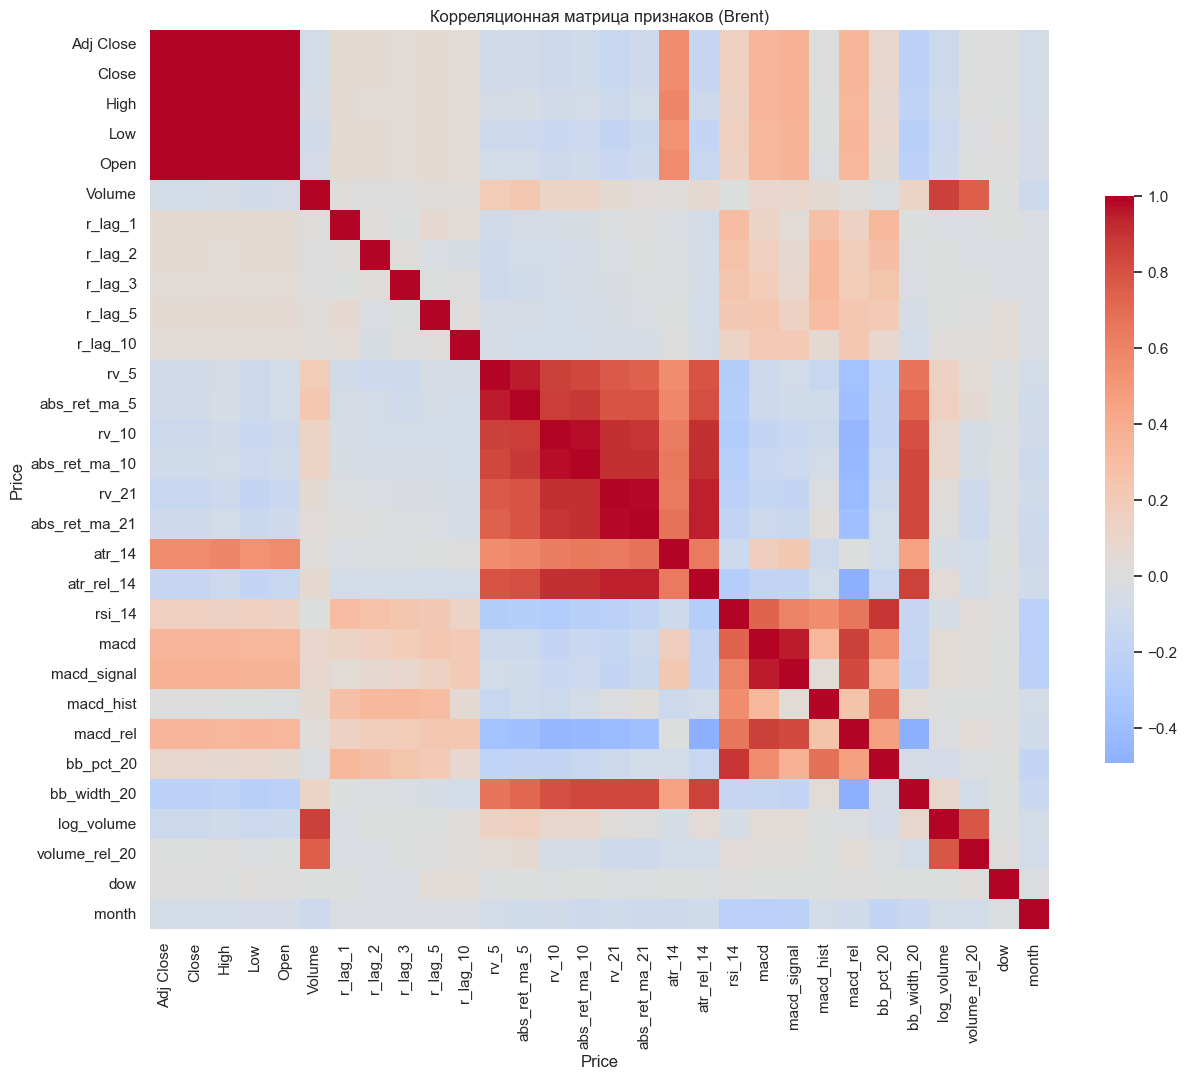

In [20]:
# Корреляционная матрица числовых признаков
num = feat_df.select_dtypes("number").drop(
    columns=[c for c in ("future_return", "log_return_t", "pct_return_t") if c in feat_df.columns]
)
corr = num.corr()
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Корреляционная матрица признаков (Brent)")
plt.tight_layout(); plt.show()

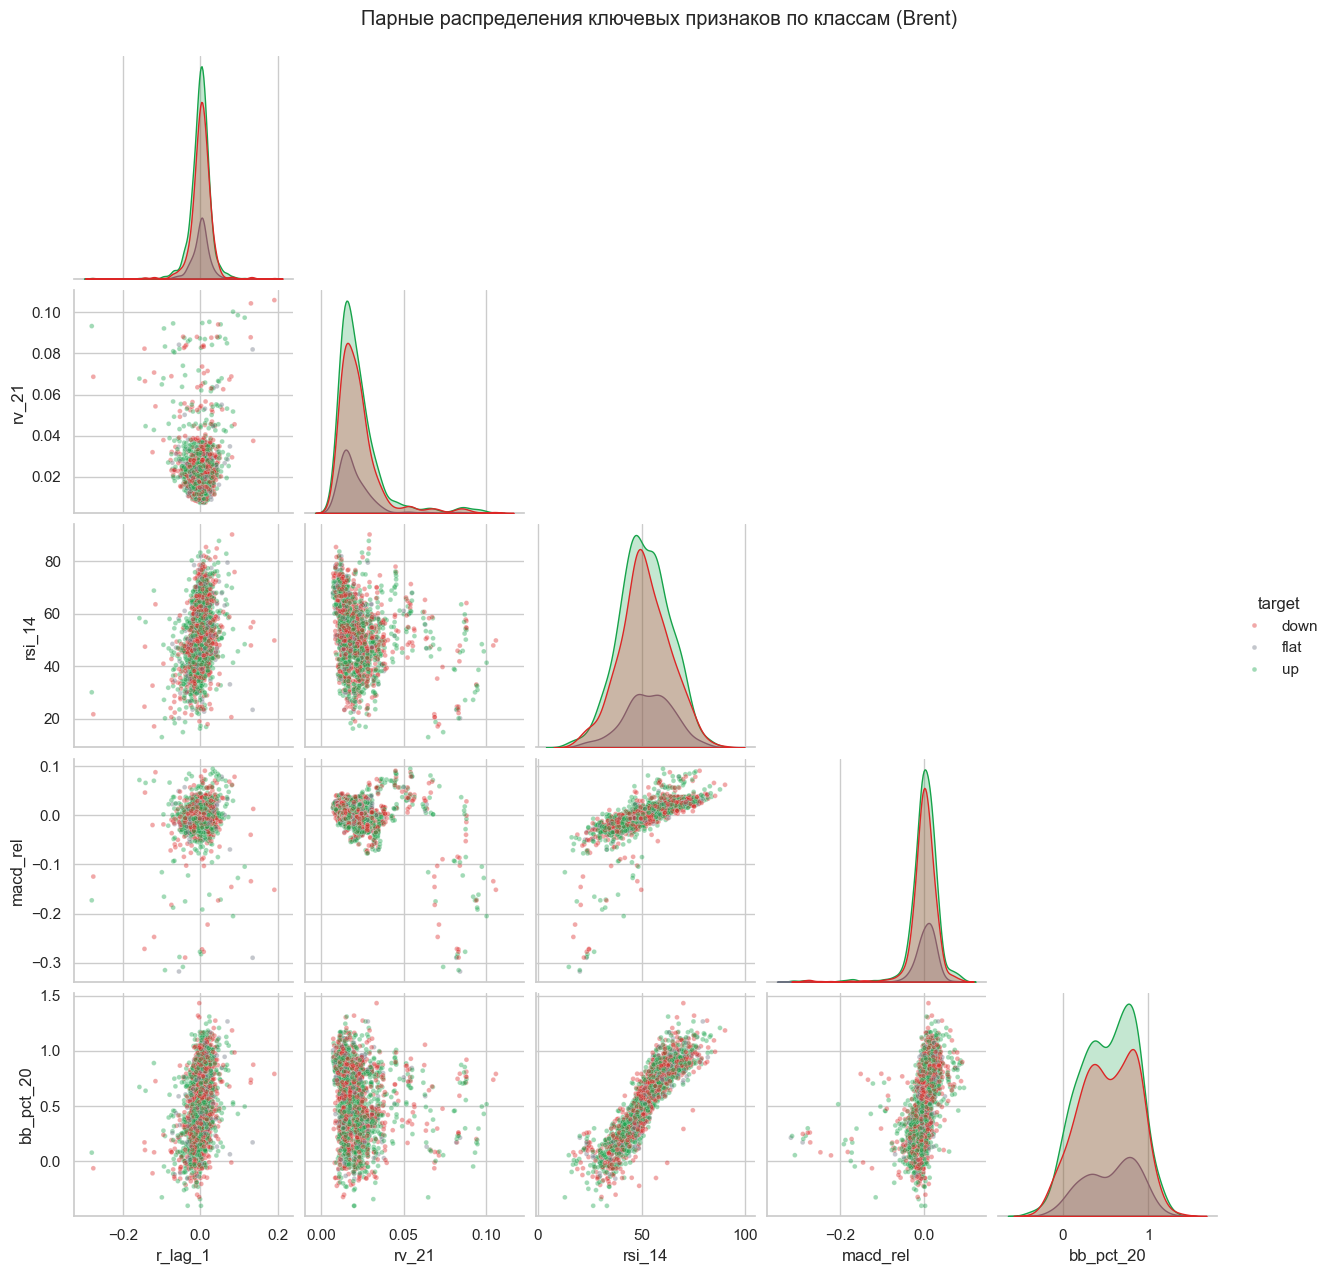

In [21]:
# Парные распределения ключевых признаков, раскрашенные по классу таргета
key = ["r_lag_1", "rv_21", "rsi_14", "macd_rel", "bb_pct_20", "target"]
sub = feat_df[key].dropna()
g = sns.pairplot(
    sub, hue="target", hue_order=["down", "flat", "up"],
    palette={"down": "#dc2626", "flat": "#6b7280", "up": "#16a34a"},
    corner=True, plot_kws={"s": 12, "alpha": 0.4},
)
g.fig.suptitle("Парные распределения ключевых признаков по классам (Brent)", y=1.02)
plt.show()

**Вывод 11c.** На корреляционной матрице видны ожидаемые блоки: лаги
доходностей слабо коррелируют между собой (рынок близок к эффективному),
а группы волатильности (`rv_*`, `atr_*`, `abs_ret_ma_*`) сильно
взаимосвязаны - это мотивирует отбор признаков на чекпоинте 5. На pairplot
классы up/down/flat сильно перекрываются по любой паре признаков - прямой
визуальный признак того, что линейной границы нет и задача требует
нелинейных моделей.

## 12. Резюме и план на чекпоинте 3

**Готово в чекпоинте 2:**

1. Собраны дневные котировки Brent, WTI, BTC с 2018-01-01 по сегодняшний день.
2. Описательные статистики, тесты стационарности (ADF/KPSS), ACF/PACF -
   подтверждают стандартные стилизованные факты (нестационарные цены,
   стационарные доходности, volatility clustering).
3. Идентифицированы и сохранены экономически значимые "выбросы" (COVID, OPEC,
   геополитика) - они не маскируются как шум.
4. Построен таргет `up/down/flat` с порогом $0.1\sigma$ - доли классов
   сбалансированы, flat не схлопывается.
5. Собран GDELT-сигнал (объём упоминаний, средний тон) по двум темам - нефть
   и BTC. Подтверждена положительная корреляция объёма новостей с реализованной
   волатильностью.

**Метрика-якорь:** macro-F1 (по 3 классам), вспомогательные - accuracy,
balanced accuracy, ROC-AUC (one-vs-rest).

**Что в чекпоинте 3 (`notebooks/ML.ipynb`):**

* Baseline'ы: "всегда мажоритарный класс", "random by class freq",
  KNN, Logistic Regression, ARIMAX-как-классификатор (через знак прогноза).
* Time-aware split (expanding window) - никогда не перемешиваем.
* Fежная feature-инженерия: lag-доходности, rolling-σ, RSI/MACD, GDELT-фичи
  (count, tone, normalized count), VADER-агрегат по сэмплу статей.
* Сравнение "только цена" vs "цена + текст" - ablation, аналогично Ghali et al.
  (2025, §4.3).

**Открытые вопросы / risk log:**

* Лимиты GDELT API (rate-limit) - на чекпоинте 3 рассмотрим параллельный canon источник
  (NewsAPI/Alpha Vantage).
* Для Reddit нужен бесплатный API-ключ; запасной вариант - Kaggle-датасет
  исторических постов r/Bitcoin / r/WallStreetBets.
* На DL-этапе (чекпоинт 6) - fine-tune FinBERT/CrudeBERT (Kaplan et al., 2023) на
  собранных GDELT-заголовках; нужна GPU.